<a href="https://colab.research.google.com/github/Nancyrana1/scikit-learn/blob/main/oppe2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP 2026 Term 1 OPPE 2
**Date:** 25th April 2026

In [409]:
# @title Student's Details to be filled before the exam starts: {"run":"auto","vertical-output":true,"form-width":"100%","display-mode":"form"}

Student_Name = "Nancy" # @param {type:"string"}
Student_Roll_No = "24f2003925" # @param {type:"string"}

try:
  if len(Student_Name) == 0:
    raise ValueError("Warning:  Please write your name")
  elif len(Student_Roll_No)==0:
    raise ValueError("Warning: Please write your roll number")

  else:
    print(f"Best Of Luck {Student_Name}({Student_Roll_No})")

except ValueError as e:
  print(e)

Best Of Luck Nancy(24f2003925)


# Unit 1 of 2: Preprocessing

### Q. 1:

In [410]:
import pandas as pd
import numpy as np


In [411]:
df = pd.read_csv("/content/MLP_OPPE2_26T1_preprocessing_V1.csv")

In [412]:
df.head()

,id,age,gender,ethnicity,smoker,family_history,hypertension_history,bmi,systolic_bp,glucose,marker,diagnosis
0,0,41.0,Female,White,Never,0.0,0,NaN,131,106,6.86,1
1,1,41.0,Male,Hispanic,Current,0.0,0,29.3,104,105,6.23,0
2,2,42.0,Male,White,Current,0.0,0,27.1,100,125,7.74,1
3,3,54.0,Female,White,Current,0.0,1,26.7,99,92,6.47,0
4,4,53.0,Male,Black,Current,0.0,0,27.4,137,100,5.23,0


In [413]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    20000 non-null  int64  
 1   age                   18227 non-null  float64
 2   gender                18838 non-null  object 
 3   ethnicity             20000 non-null  object 
 4   smoker                20000 non-null  object 
 5   family_history        18064 non-null  float64
 6   hypertension_history  20000 non-null  int64  
 7   bmi                   18244 non-null  float64
 8   systolic_bp           20000 non-null  int64  
 9   glucose               20000 non-null  int64  
 10  marker                20000 non-null  float64
 11  diagnosis             20000 non-null  int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 1.8+ MB


In [414]:
df.describe()

,id,age,family_history,hypertension_history,bmi,systolic_bp,glucose,marker,diagnosis
count,20000.000000,18227.000000,18064.000000,20000.000000,18244.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,9999.500000,49.931201,0.214847,0.254000,25.642025,115.674950,111.047400,6.522129,0.60000
std,5773.647028,15.595378,0.410728,0.435308,3.570019,14.220485,13.530691,0.814493,0.48991
min,0.000000,18.000000,0.000000,0.000000,15.000000,90.000000,60.000000,4.000000,0.00000
25%,4999.750000,39.000000,0.000000,0.000000,23.200000,105.000000,102.000000,5.970000,0.00000
50%,9999.500000,50.000000,0.000000,0.000000,25.700000,116.000000,111.000000,6.520000,1.00000
75%,14999.250000,61.000000,0.000000,1.000000,28.000000,125.000000,120.000000,7.080000,1.00000
max,19999.000000,90.000000,1.000000,1.000000,39.000000,174.000000,163.000000,9.510000,1.00000


In [415]:
df["smoker"].unique()

array(['Never', 'Current', 'Former'], dtype=object)

In [416]:
df["hypertension_history"].value_counts()

,count
hypertension_history,
0,14920
1,5080


In [417]:
print(5080/20000)

0.254


### Q. 2:

In [467]:
df["smoker"].unique()

array(['Never', 'Current', 'Former'], dtype=object)

### Q. 3:

In [418]:
avg_glucose = df.groupby("ethnicity")["glucose"]
highest_ethnicity = avg_glucose.idxmax()
print(highest_ethnicity)

ethnicity
Asian        4273
Black       12762
Hispanic    13138
Other        3275
White        9671
Name: glucose, dtype: int64


### Q. 4:

In [419]:
df['marker'].describe()

,marker
count,20000.000000
mean,6.522129
std,0.814493
min,4.000000
25%,5.970000
50%,6.520000
75%,7.080000
max,9.510000


### Q. 5:

In [420]:
cur = df[df["smoker"]=="Current"]
cur.head()

,id,age,gender,ethnicity,smoker,family_history,hypertension_history,bmi,systolic_bp,glucose,marker,diagnosis
1,1,41.0,Male,Hispanic,Current,0.0,0,29.3,104,105,6.23,0
2,2,42.0,Male,White,Current,0.0,0,27.1,100,125,7.74,1
3,3,54.0,Female,White,Current,0.0,1,26.7,99,92,6.47,0
4,4,53.0,Male,Black,Current,0.0,0,27.4,137,100,5.23,0
8,8,24.0,Male,Asian,Current,1.0,0,21.3,112,105,6.08,0


In [421]:
female = len(cur[cur["gender"]=="Female"])
male = len(cur[cur["gender"]=="Male"])

ratio = female/male

ratio_trunc = int(ratio*100)/100

print(ratio_trunc)

1.04


### Q. 6:



In [422]:
X = df.drop(columns=["id","diagnosis"],axis=1)
y = df["diagnosis"]

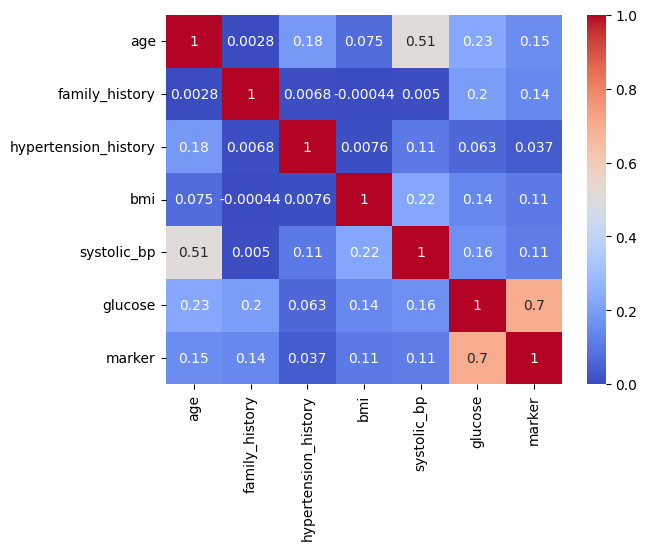

In [469]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols=['age', "family_history", "hypertension_history" ,  "bmi" , "systolic_bp" , "glucose", "marker ","diagnosis" ]
corr_matrix = X.corr(numeric_only=True)
# print(corr_matrix)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


In [424]:
X['age'].median()

50.0

In [425]:
X["bmi"].mean()

np.float64(25.64202477526858)

In [426]:
X.isnull().sum()

,0
age,1773
gender,1162
ethnicity,0
smoker,0
family_history,1936
hypertension_history,0
bmi,1756
systolic_bp,0
glucose,0
marker,0


### Q. 7:

In [470]:
from sklearn.model_selection import train_test_split

### Q. 8:

In [427]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer



In [428]:
bmi_imputed=X["bmi"].mean()
X["bmi"] = X["bmi"].replace(np.nan,bmi_imputed)

gender_imputed=X["gender"].mode()[0]
X["gender"] = X["gender"].replace(np.nan,gender_imputed)


age_imputed=X["age"].median()
X["age"] = X["age"].replace(np.nan,age_imputed)

X['family_history'] = X["family_history"].fillna(2)

In [429]:
X["bmi"].mean()

np.float64(25.64202477526858)

In [430]:
X['age'].unique()

array([41., 42., 54., 53., 32., 58., 24., 18., 68., 90., 52., 33., 66.,
       49., 35., 46., 50., 65., 39., 72., 60., 69., 59., 56., 44., 51.,
       80., 38., 79., 36., 29., 67., 48., 22., 57., 47., 31., 63., 62.,
       64., 73., 76., 55., 83., 34., 37., 30., 28., 74., 85., 75., 20.,
       40., 78., 26., 27., 61., 70., 77., 81., 45., 86., 25., 23., 21.,
       43., 19., 82., 71., 84., 89., 88., 87.])

In [431]:
X['bmi'].unique()

array([25.64202478, 29.3       , 27.1       , 26.7       , 27.4       ,
       25.2       , 32.2       , 27.3       , 21.3       , 23.4       ,
       20.8       , 28.6       , 21.2       , 29.2       , 22.4       ,
       27.7       , 18.1       , 24.4       , 24.5       , 19.5       ,
       24.7       , 23.5       , 19.1       , 18.9       , 26.        ,
       30.8       , 28.2       , 19.2       , 19.4       , 24.3       ,
       26.6       , 20.2       , 22.5       , 23.8       , 28.        ,
       26.2       , 26.8       , 29.6       , 24.        , 33.2       ,
       28.7       , 21.1       , 19.7       , 25.8       , 26.1       ,
       34.2       , 25.4       , 21.7       , 27.2       , 25.7       ,
       25.5       , 19.9       , 31.9       , 26.3       , 21.8       ,
       28.8       , 24.2       , 24.9       , 23.3       , 23.6       ,
       32.7       , 29.8       , 21.        , 23.2       , 25.3       ,
       18.5       , 35.6       , 26.5       , 21.6       , 28.3 

In [432]:
X.isnull().sum()

,0
age,0
gender,0
ethnicity,0
smoker,0
family_history,0
hypertension_history,0
bmi,0
systolic_bp,0
glucose,0
marker,0


In [433]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [434]:
print(y_test.sum())

2398


In [435]:
y_test.head()

,diagnosis
10650,0
2041,1
8668,1
1114,1
13902,0


In [436]:
X_train.isnull().sum()

,0
age,0
gender,0
ethnicity,0
smoker,0
family_history,0
hypertension_history,0
bmi,0
systolic_bp,0
glucose,0
marker,0


### Q. 9:

In [437]:
X["age"].median()

50.0


### Q. 10:

In [438]:
X["gender"].mode()[0]

'Female'

In [439]:
X_train.isnull().sum()

,0
age,0
gender,0
ethnicity,0
smoker,0
family_history,0
hypertension_history,0
bmi,0
systolic_bp,0
glucose,0
marker,0


QUESTION 11

In [440]:
smoker_map={
    "Never" : 0,
    "Former" : 1,
    "Current" : 2
}
X_train["smoker"] = X_train["smoker"].map(smoker_map)
X_test["smoker"] = X_test["smoker"].map(smoker_map)

In [441]:
X_train = pd.get_dummies(X_train,columns=["gender","ethnicity"],drop_first=True)
X_test = pd.get_dummies(X_test,columns=["gender","ethnicity"],drop_first=True)

X_train, X_test = X_train.align(X_test, join='inner', axis=1)

In [442]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [443]:
total_sum_100_feature_matrix = X_train_scaled[:100].sum()
print(round(total_sum_100_feature_matrix,2))

56.08


In [444]:
total_sum_test_feature_matrix = X_test_scaled.sum()
print(round(total_sum_test_feature_matrix,2))

-109.95


# Unit 2 of 2: Model Building

# Please regularly save your Answers in the exam portal by clicking on "Submit" button

In [445]:
df1 = pd.read_csv("/content/MLP_OPPE2_26T1_modelBuilding_V3.csv")

In [446]:
df1.shape

(20000, 15)

In [447]:
df1.head()

,smoker,gender_Male,gender_Other,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,bmi,age,family_history,hypertension_history,systolic_bp,glucose,marker,diagnosis
0,1.726874,-0.876108,-0.127262,-0.465543,-0.498339,-0.23032,1.095546,-1.532886,1.045744,-0.572153,-0.579275,-0.499492,0.575190,-0.471444,0
1,-0.756273,1.141412,-0.127262,-0.465543,-0.498339,-0.23032,-0.912787,0.099043,0.379371,1.023811,-0.579275,1.042164,1.093342,0.091936,1
2,-0.756273,1.141412,-0.127262,-0.465543,-0.498339,-0.23032,1.095546,-0.101370,-0.486915,-0.572153,1.726296,0.691788,0.575190,1.218694,1
3,-0.756273,1.141412,-0.127262,-0.465543,-0.498339,-0.23032,-0.912787,0.328085,-0.420278,2.619776,-0.579275,0.551637,-0.905243,-0.495938,1
4,-0.756273,1.141412,-0.127262,-0.465543,2.006665,-0.23032,-0.912787,0.156303,1.245656,-0.572153,1.726296,0.341411,1.093342,0.753294,1


In [448]:
df1.describe()

,smoker,gender_Male,gender_Other,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,bmi,age,family_history,hypertension_history,systolic_bp,glucose,marker,diagnosis
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,-0.008288,-0.004237,0.006887,-0.001633,0.003413,-0.001486,-0.001305,-0.002378,-0.003591,0.005985,-0.001268,-0.001176,0.000075,0.000506,0.60000
std,0.995922,0.999454,1.026278,0.998649,1.002590,0.996964,0.999905,1.003720,0.996870,1.002089,0.999297,0.996722,1.001485,1.000117,0.48991
min,-0.756273,-0.876108,-0.127262,-0.465543,-0.498339,-0.230320,-0.912787,-3.050293,-2.152848,-0.572153,-0.579275,-1.830923,-3.792088,-3.092381,0.00000
25%,-0.756273,-0.876108,-0.127262,-0.465543,-0.498339,-0.230320,-0.912787,-0.645346,-0.686827,-0.572153,-0.579275,-0.709718,-0.683178,-0.679649,0.00000
50%,-0.756273,-0.876108,-0.127262,-0.465543,-0.498339,-0.230320,-0.912787,0.000000,-0.020453,-0.572153,-0.579275,-0.008965,-0.016983,-0.006043,1.00000
75%,0.485300,1.141412,-0.127262,-0.465543,-0.498339,-0.230320,1.095546,0.643019,0.645920,1.023811,1.726296,0.691788,0.649212,0.667562,1.00000
max,1.726874,1.141412,7.857805,2.148031,2.006665,4.341787,1.095546,3.792355,2.645040,2.619776,1.726296,4.405779,3.832143,3.888621,1.00000


In [449]:
X_df1 = df1.drop(columns=["diagnosis"],axis=1)
y_df1 = df1["diagnosis"]

In [450]:
X_train_df1 , X_test_df1 , y_train_df1 , y_test_df1 = train_test_split(X_df1,y_df1,test_size=0.2,random_state=42)

### Q.1:

In [451]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Ridge


In [452]:
perceptron = Perceptron(
    penalty = "l2", max_iter=500,
    early_stopping=True, n_iter_no_change=5 , random_state=42)


perceptron.fit(X_train_df1,y_train_df1)


Perceptron(early_stopping=True, max_iter=500, penalty='l2', random_state=42)

In [453]:
print(perceptron.intercept_)

[5.]


### Q. 2:

In [454]:
y_pred = perceptron.predict(X_test_df1)
accuracy_score(y_test_df1,y_pred)

0.79475

### Q. 3:

In [455]:
accuracy_score(y_test_df1,y_pred)

0.79475

### Q. 4:

In [456]:
from sklearn.svm import SVC

svc = SVC(
    C = 0.1, kernel = "poly",
    degree = 2
)

svc.fit(X_train_df1,y_train_df1)

total_number_of_support_vector=svc.n_support_.sum()
print(total_number_of_support_vector)

13064


### Q. 5:

In [457]:
from sklearn.metrics import precision_score
y_pred = svc.predict(X_test_df1)
precision_score(y_test_df1,y_pred)

precision_score_truncated = int(precision_score(y_test_df1,y_pred)*1000)/1000
print(precision_score_truncated)

0.606


### Q. 6:



In [458]:
from sklearn.tree import DecisionTreeClassifier

dtc_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    min_samples_split=3,
    min_impurity_decrease=0.01,
    random_state=42
)

dtc_model.fit(X_train_df1,y_train_df1)


DecisionTreeClassifier(criterion='entropy', max_depth=5,
                       min_impurity_decrease=0.01, min_samples_split=3,
                       random_state=42)

### Q. 7:

In [459]:
print(dtc_model.get_depth())

2


### Q. 8:

In [460]:
root_entropy = dtc_model.tree_.impurity[0]

root_entropy_truncated = int(root_entropy*1000)/1000
print(root_entropy_truncated)

0.971


In [461]:
index_of_feature = np.argmax(dtc_model.feature_importances_)
print(index_of_feature)

13


### Q. 9:

In [463]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.pipeline import Pipeline


pipeline = Pipeline([
    ('select', SelectKBest(score_func=f_classif)),
    ('knn', KNeighborsClassifier())
])

param_grid={
        'select__k': [3, 6, 10, 14],
        'knn__n_neighbors': [3, 5, 7, 9, 11],
        'knn__weights': ['uniform', 'distance']
    }

grid_cv = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_cv.fit(X_train_df1, y_train_df1)

# best_params = grid_cv.best_params_
# print(best_params)

best_score_truncated = int(grid_cv.best_score_*1000)/1000
print(best_score_truncated)


0.907


### Q. 10:

In [464]:
print(grid_cv.best_params_['select__k'])

3


### Q. 11:

In [466]:
from sklearn.metrics import accuracy_score
y_pred = grid_cv.best_estimator_.predict(X_test_df1)

misclassified_samples = (y_pred != y_test_df1).sum()
# accuracy_score_truncated = int(accuracy_score(y_test_df1,y_pred)*1000)/1000
# print(accuracy_score_truncated)

misclassified_samples


np.int64(363)